# Central North Greenland (Victoria Fjord) dolerite dykes ca. 1382 Ma paleomagnetic pole

## Geologic context

These middle-Proterozoic basic dykes cut Archaean basement exposed as nunataks at
the head of Victoria Fjord in central North Greenland (81.5°N, 44.7°W;
Abrahamsen & Van der Voo, 1987). Their characteristic remanence is of a single
polarity that is antiparallel to that of the comagmatic Zig-Zag Dal Basalts and
Midsommerso Dolerites of eastern North Greenland, and confirms that Greenland was
part of the North American craton in the Mesoproterozoic. The dyke magnetization
is shown to be primary by a detailed positive baked-contact test.

## Pole

This notebook recreates the central North Greenland dolerite pole at the dyke
level from the 9 dyke sites of Abrahamsen & Van der Voo (1987), with the site
longitude and per-site VGPs corrected. The age is adopted as 1382 ± 2 Ma by
correlation with the U-Pb-dated Midsommerso Dolerites (Upton et al., 2005); the
paper itself infers ~1.25 Ga from Rb-Sr — a genuine age uncertainty.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data and the dyke pole

Loaded from `../data/1382_Victoria_Fjord/`. The pole uses the 9 accepted dyke
sites (D1-D9); D10 (a discordant easterly direction, α95 18.5°) is excluded.

In [2]:
sites_geo, _ = pt.load_magic_sites('../data/1382_Victoria_Fjord/sites.txt')
study_lat, study_lon = 81.5, 315.3
print(f'{len(sites_geo)} accepted dyke sites')
sites_geo[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_alpha95', 'dir_k', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

9 accepted dyke sites


,site,lat,lon,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,vgp_lat,vgp_lon
0,D1,81.5,315.3,265.0,21.0,7.6,41.0,10.0,10.0,231.9
1,D2,81.5,315.3,264.0,29.0,7.9,38.0,10.0,14.4,233.6
2,D3,81.5,315.3,273.0,20.0,4.4,121.0,10.0,10.6,223.9
3,D4,81.5,315.3,268.0,21.0,5.5,150.0,6.0,10.4,228.9
4,D5,81.5,315.3,274.0,14.0,1.6,1807.0,6.0,7.6,222.4
5,D6,81.5,315.3,275.0,28.0,4.6,149.0,8.0,15.5,222.6
6,D7,81.5,315.3,258.0,29.0,6.1,72.0,9.0,13.6,239.4
7,D8,81.5,315.3,260.0,37.0,6.9,56.0,5.0,18.9,238.3
8,D9,81.5,315.3,256.0,27.0,6.2,152.0,5.0,12.1,241.2


Plon: 231.3  Plat: 12.7
Number of directions in mean (n): 9
Angular radius of 95% confidence (A_95): 5.1
Precision parameter (k) estimate: 104.1

prior compilation (Victoria Fjord, GPMDB 489): 10.3 N / 231.7 E, A95 5.9, N=12
Abrahamsen & Van der Voo (1987) observed pole (before rotation): ~12.5 N / 232 E


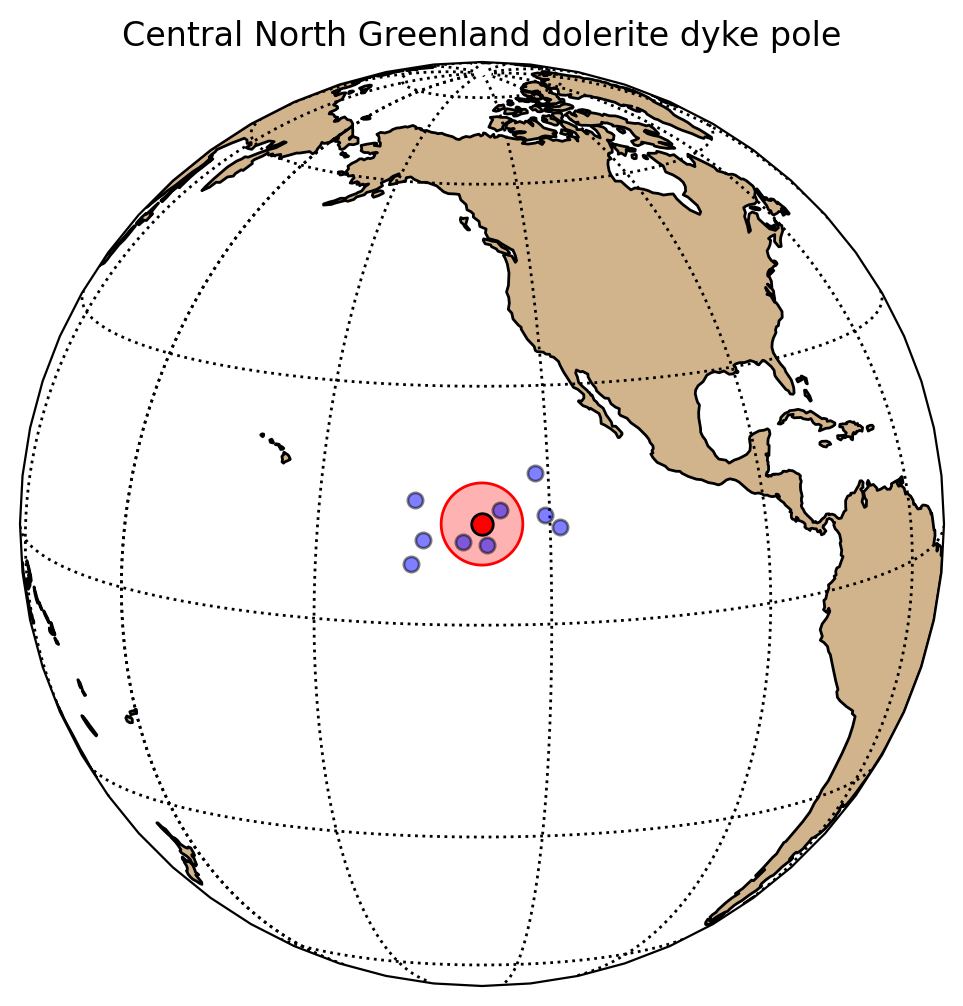

In [3]:
vgp_block, pole_mean = pt.compute_mean_pole(sites_geo, unify_polarity=True)
if pole_mean['inc'] < 0:
    vgp_block, pole_mean = pt.compute_mean_pole(sites_geo, unify_polarity=True, flip=True)
ipmag.print_pole_mean(pole_mean)
print('\nprior compilation (Victoria Fjord, GPMDB 489): 10.3 N / 231.7 E, A95 5.9, N=12')
print('Abrahamsen & Van der Voo (1987) observed pole (before rotation): ~12.5 N / 232 E')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Central North Greenland dolerite dyke pole')
plt.show()

Dec: 266.1  Inc: 25.3
Number of directions in mean (n): 9
Angular radius of 95% confidence (a_95): 5.9
Precision parameter (k) estimate: 75.8


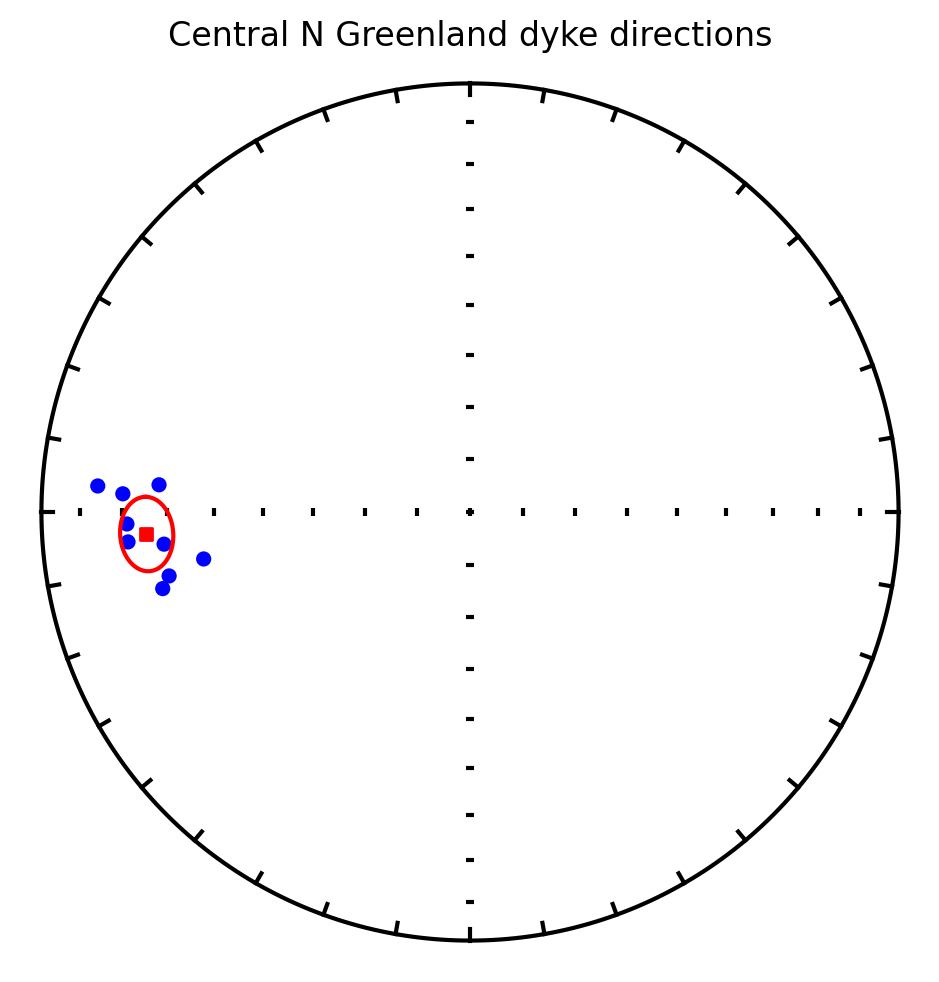

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(sites_geo, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('Central N Greenland dyke directions')
plt.show()

## Field test: baked contact

Abrahamsen & Van der Voo (1987) sampled three baked gneiss sites adjacent to the
dykes; the baked Archaean gneiss carries the dyke direction, a positive
baked-contact test confirming the dyke magnetization is primary (the baked-gneiss
sites are not in this site-level table but are documented in the paper).

## Paleosecular variation

A_95 of 5.1 passes Deenen et al. (2011) criteria of being between 5.0 and 20.5 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

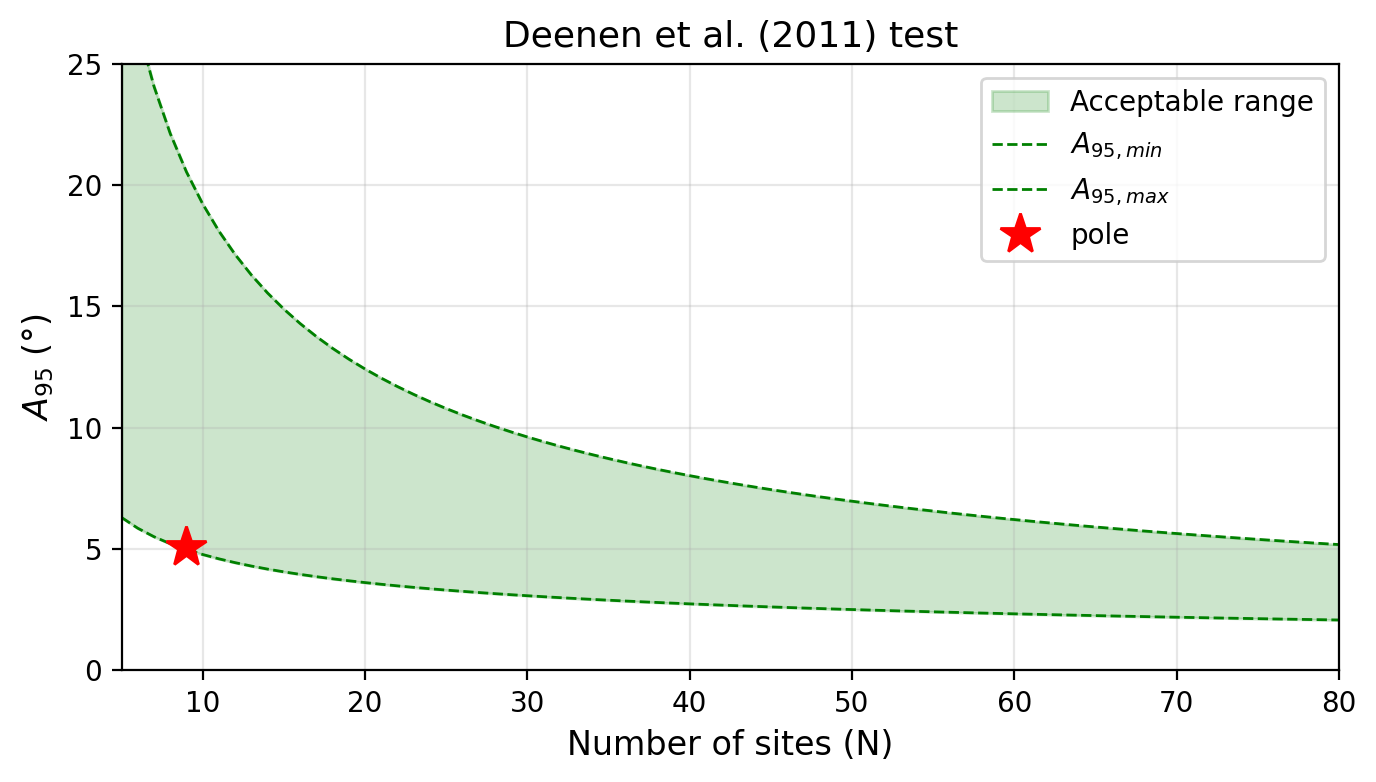

In [5]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

In [6]:
fishqq_result = pt.fishqq_vgps(sites_geo, unify_polarity=True)
fishqq_result

you need N> 10 for at least one mode


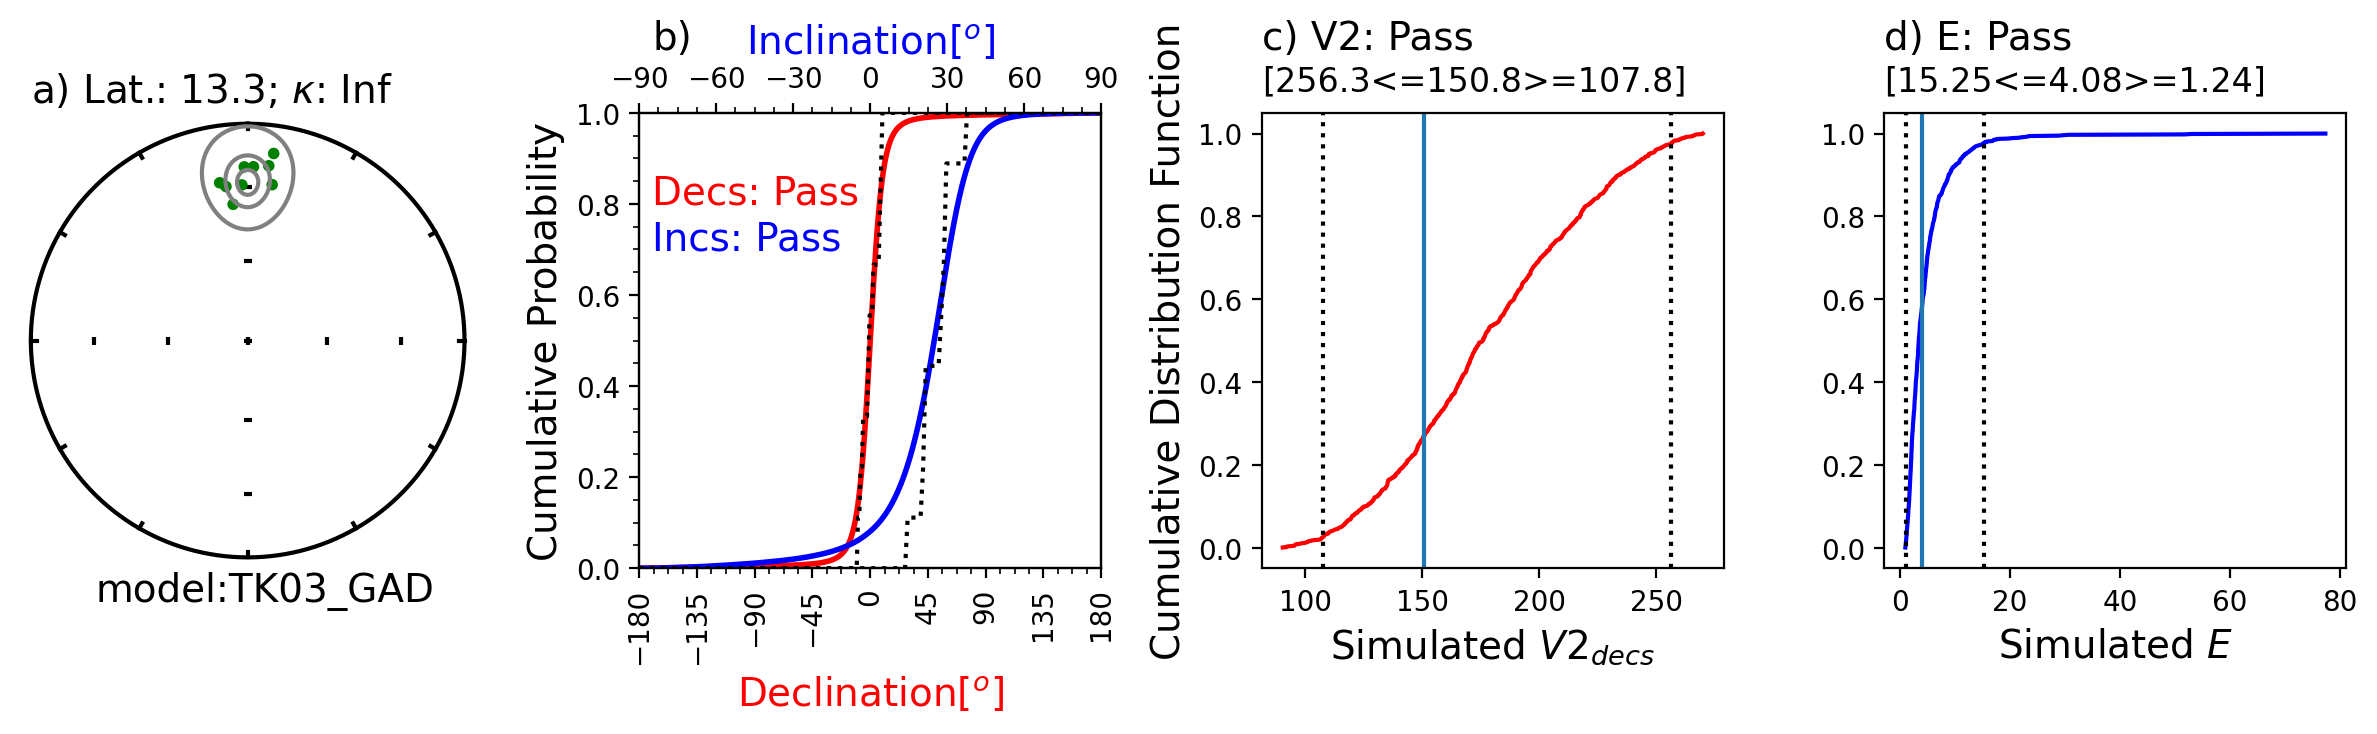

paleolatitude = 13.3 deg; elongation E = 4.08 (consistent with TK03.GAD)


In [7]:
_slat, _slon = float(sites_geo['lat'].mean()), float(sites_geo['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(sites_geo, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(sites_geo, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The pole in the context of the Laurentia APWP

posx and posy should be finite values
posx and posy should be finite values


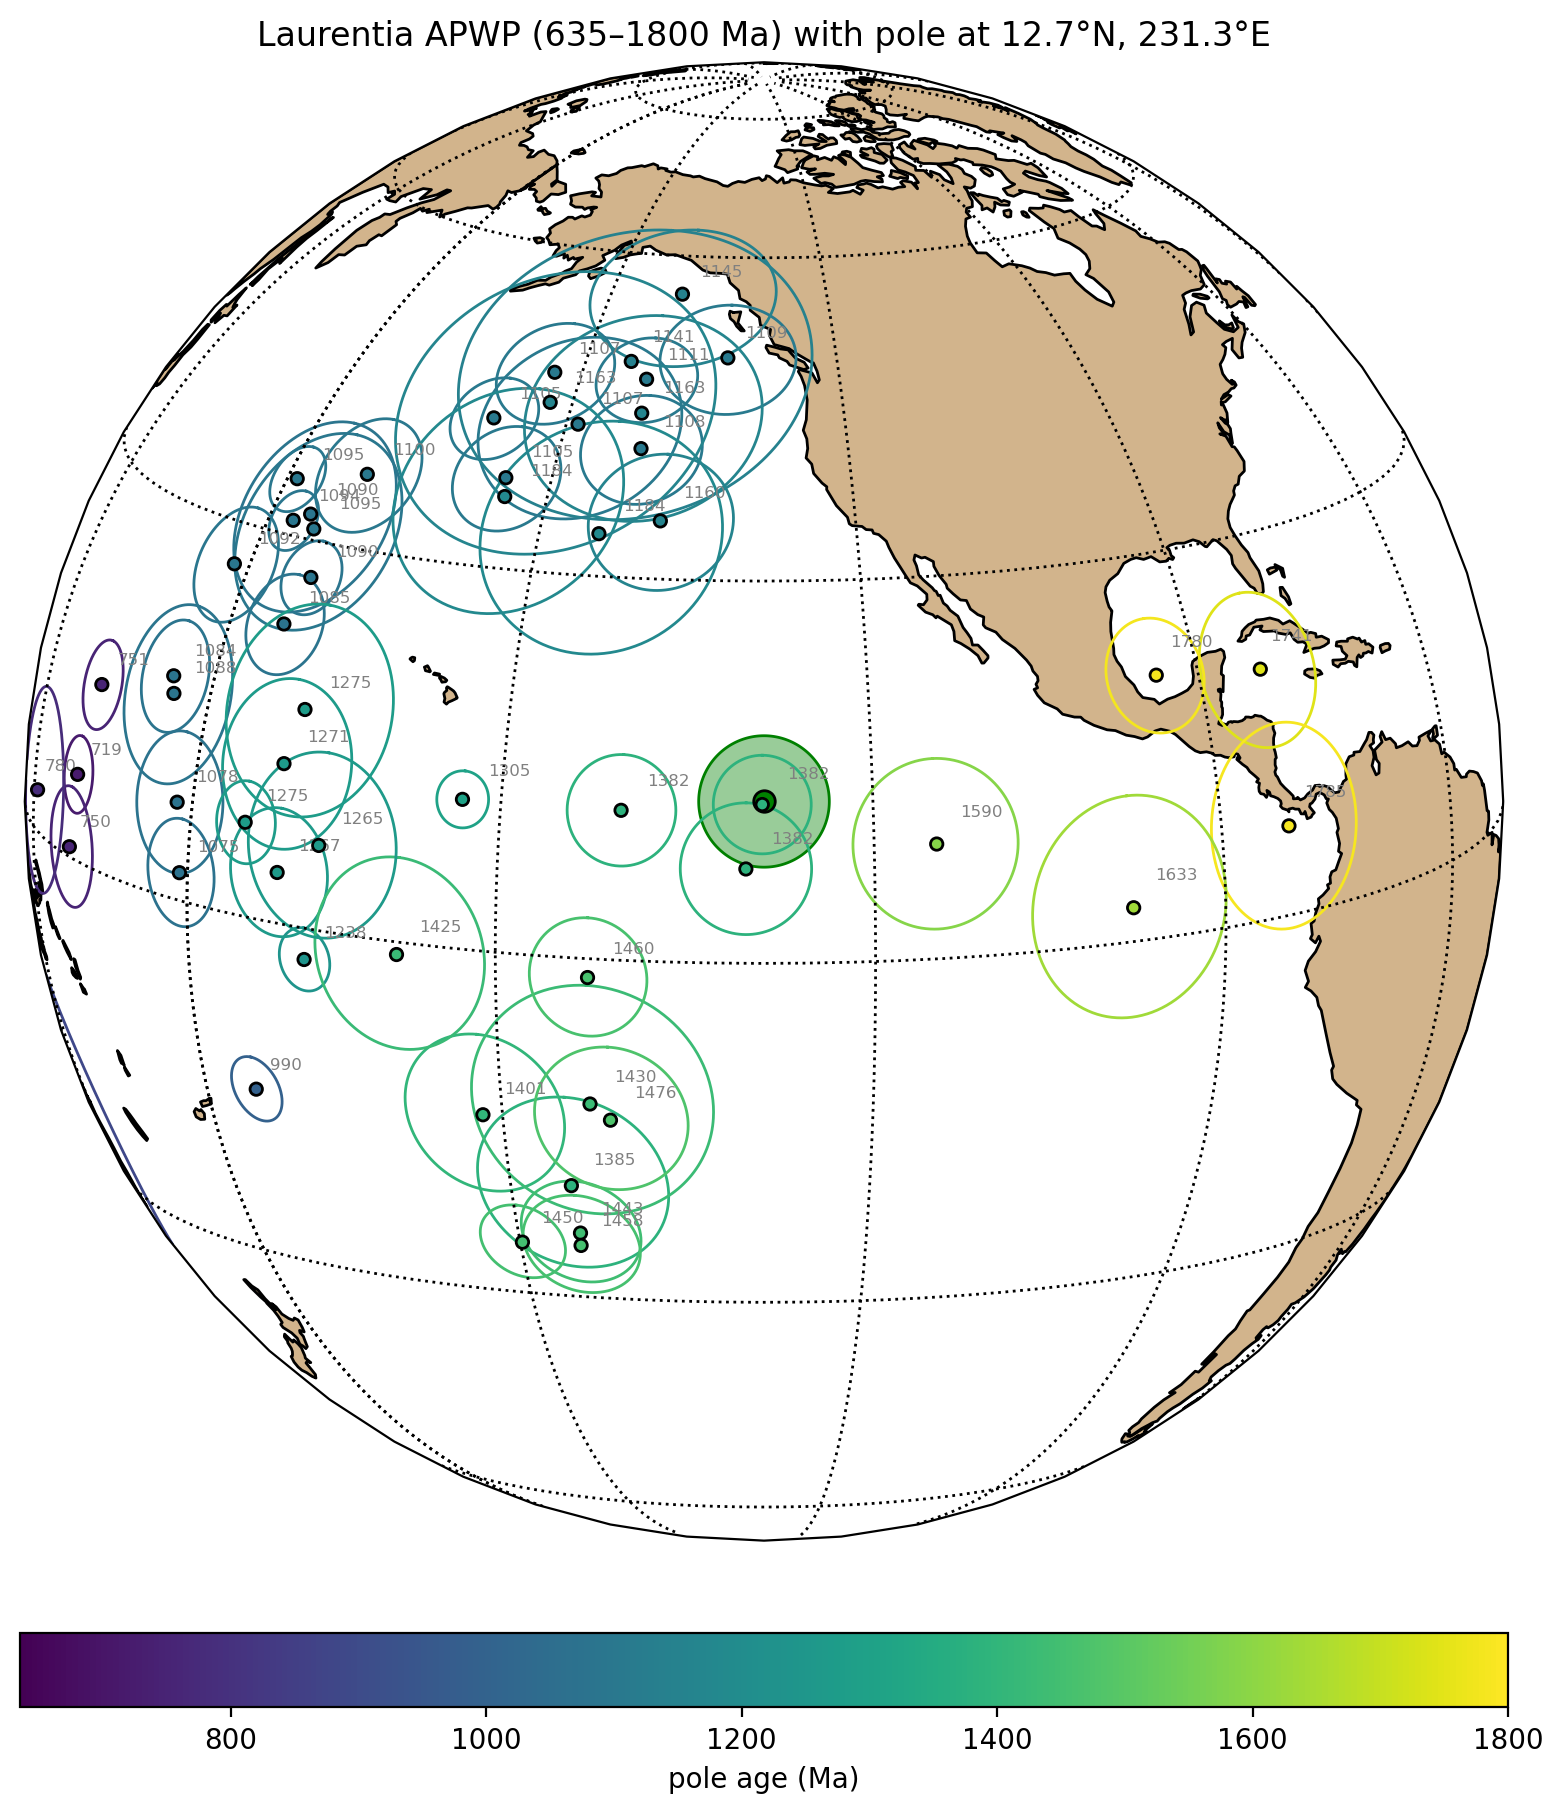

In [8]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

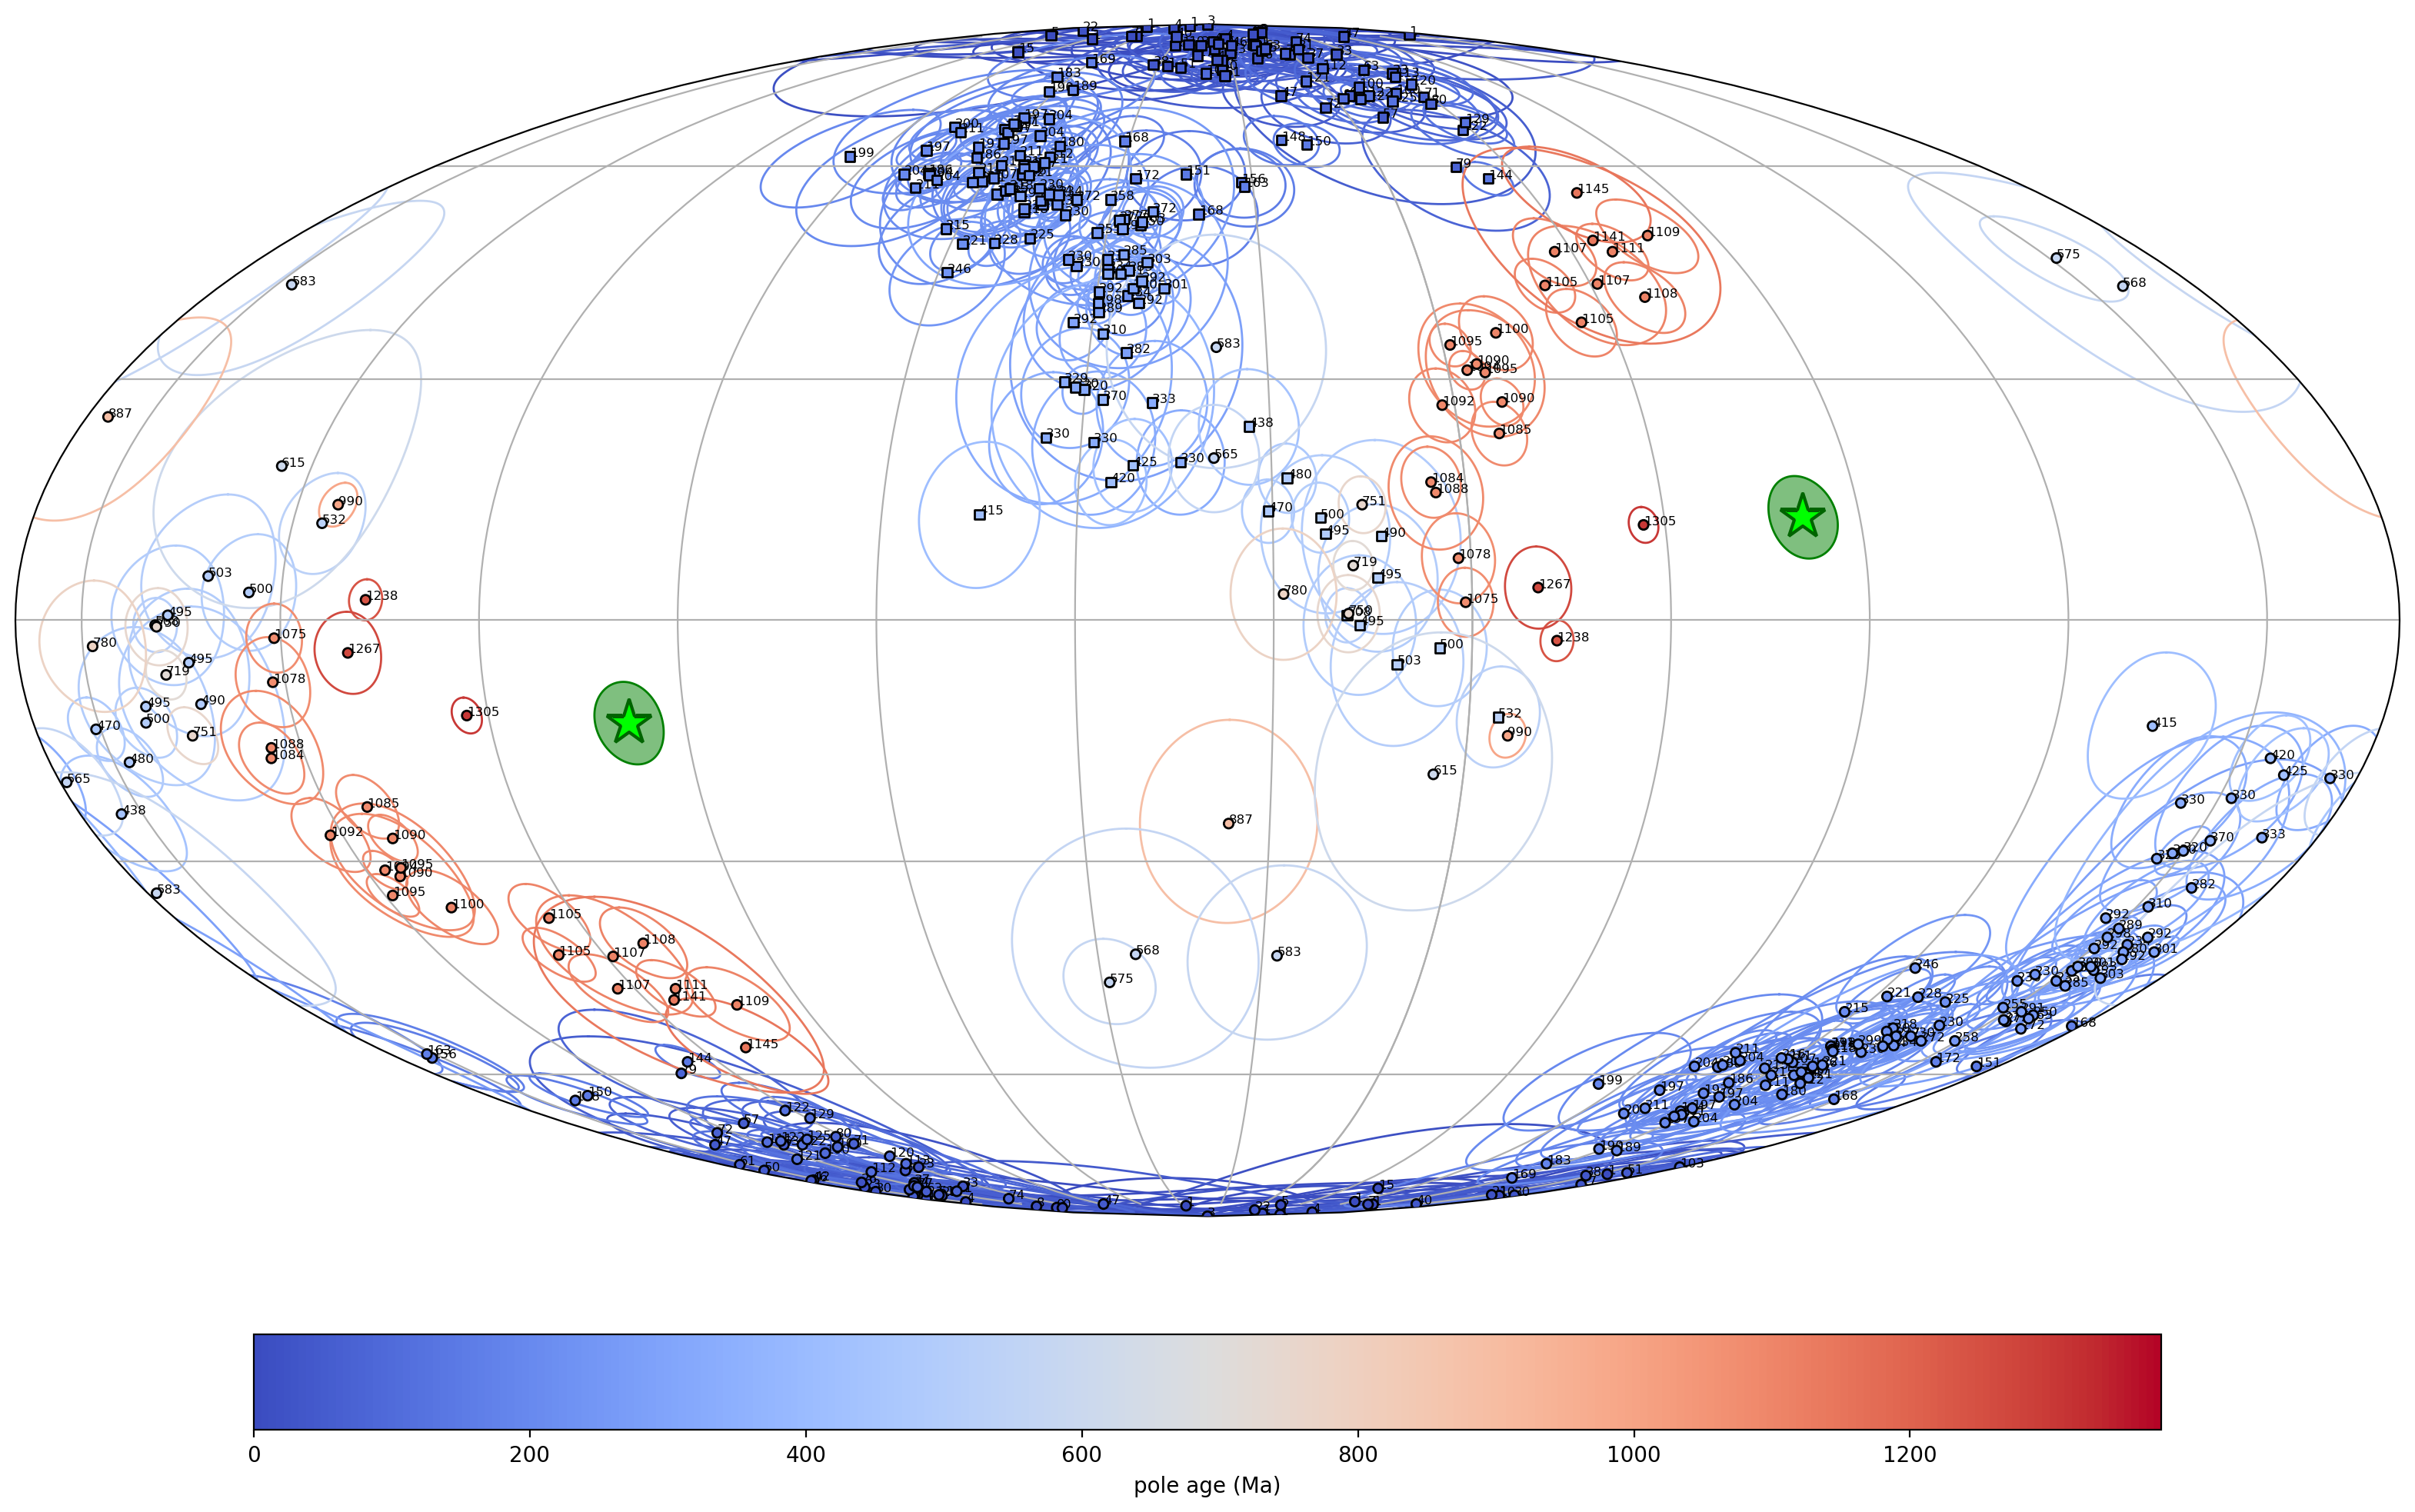

<GeoAxesSubplot:>

In [9]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Victoria Fjord dolerite dykes', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1382)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | Age adopted as 1382 ± 2 Ma by correlation with the U-Pb-dated Midsommerso Dolerites (Upton et al., 2005). (The paper infers ~1.25 Ga from Rb-Sr — see note.) |
| 2 | Techniques and statistical analysis | **0** | AF + thermal demagnetization; the VGPs are over-concentrated (K ≈ 104 ≫ 70, A95 below the Deenen et al. (2011) lower bound), indicating under-averaged paleosecular variation. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence characterized by rock-magnetic measurements (Abrahamsen & Van der Voo, 1987). |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact test (three baked gneiss sites carry the dyke direction). |
| 5 | Structural control / tectonic coherence | **0** | Isolated nunatak exposure; possible local rotation and the unresolved age leave the structural/tectonic coherence weak. |
| 6 | Presence of reversals | **0** | Single polarity within the swarm (antiparallel to the eastern North Greenland units, but no reversal within this collection). |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **4/7** | Grade B |

## Nordic workshop summary

The central North Greenland (Victoria Fjord) dolerite pole is recreated from the
9 dyke sites of Abrahamsen & Van der Voo (1987), after correcting the site
longitude (44.7°E → 315.3°E) and recomputing VGPs. The recreation
(≈12.7°N/231.3°E, A95 5.1°) reproduces the prior compilation Victoria Fjord pole
(10.3°N/231.7°E, GPMDB 489). Positive baked-contact test (R4 = C); over-
concentrated VGPs (R2 = 0).

**Age flag for review:** the paper infers ~1.25 Ga (Rb-Sr on related intrusives);
the compilation adopts 1382 ± 2 Ma by correlation with the U-Pb-dated Midsommerso
Dolerites — a genuine age uncertainty (R1 depends on this choice).

### Dolerite dyke pole

| | This study (site VGPs) | Abrahamsen & Van der Voo (1987) | Previous Nordic compilation |
|---|---|---|---|
| Component | Dolerite dykes | Mean of Dolerites | Dolerites & Baked |
| N (sites) | 9 | 9 | 12 |
| N (specimens) | 69 | 73 | 92 |
| Dec (°) | 266.1 | 265.2 | 265.2 |
| Inc (°) | 25.3 | 25.3 | 21.5 |
| k (direction) | 75.8 | 85 | 60.0 |
| α95 (direction, °) | 5.9 | 5.6 | 5.6 |
| Pole lat (°N) | 12.7 | 12.5 | 10.3 |
| Pole lon (°E) | 231.3 | 232.0 | 231.7 |
| A95 (°) | 5.1 | — | 4.3 |
| dp / dm (°) | — | 3.3 / 6.0 | 3.1 / 5.9 |


In [10]:
victoria_summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='Victoria Fjord dolerite dykes',
    sites=sites_geo,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Primary characteristic remanent magnetization (magnetite); single polarity (antiparallel to eastern North Greenland units)',
    tests='C+ (positive baked-contact test; three baked gneiss sites carry the dyke direction)',
    gpmdb_number='489',
    percent_reversed=0,
    demag_code=3,
    R1=1, R2=0, R3=1, R4='C', R5=0, R6=0, R7=1, Grade='B',
    nominal_age=1382, lomagage=1380, himagage=1384,
    REF_method='Age adopted as 1382 +/- 2 Ma by correlation with the U-Pb baddeleyite-dated Midsommerso Dolerites (Upton et al., 2005); Abrahamsen & Van der Voo (1987) infer ~1.25 Ga from Rb-Sr on related intrusives.',
    POLE_AUTHORS='Abrahamsen, N., & Van der Voo, R.',
    YEAR=1987,
    JOURNAL='Geophysical Journal of the Royal Astronomical Society',
    VOLUME='91',
    VPAGES='597-611',
    TITLE='Palaeomagnetism of middle Proterozoic (c. 1.25 Ga) dykes from central North Greenland',
    COMMENT='Central North Greenland (Victoria Fjord) dolerite pole recreated from the 9 dyke sites of Abrahamsen & Van der Voo (1987) (audited spreadsheet: site longitude 44.7E->315.3E, D6 dec 267->275, D8 n 9->5, D10 a95 16.5->18.5 + excluded, method code + lithology Dibase->Diabase fixed; VGPs recomputed). Recreated 12.7N/231.3E, A95 5.1, N=9 -- reproduces prior compilation Victoria Fjord pole (10.3/231.7, GPMDB 489). Positive baked-contact test (R4=C; the paper describes a normal baked-contact test, so C rather than the compilation R4=c). K~104>>70 -> R2=0; single polarity R6=0. AGE FLAG: paper infers ~1.25 Ga (Rb-Sr); compilation adopts 1382+/-2 Ma via correlation with Upton 2005 -- genuine uncertainty. R=4, Grade B.'
)
pt.save_nordic_summary(victoria_summary, '1382_Victoria_Fjord')
victoria_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,Victoria Fjord dolerite dykes,GPMDB:489,Primary characteristic remanent magnetization ...,C+ (positive baked-contact test; three baked g...,0,81.5,315.3,9,69,...,1384,Age adopted as 1382 +/- 2 Ma by correlation wi...,Victoria Fjord dolerite dykes,"Abrahamsen, N., & Van der Voo, R.",1987,Geophysical Journal of the Royal Astronomical ...,91,597-611,Palaeomagnetism of middle Proterozoic (c. 1.25...,Central North Greenland (Victoria Fjord) doler...
